In [1]:
import math
import random
from typing import Iterable
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

print("✅ All libraries imported. Starting hierarchical organization analysis...")

✅ All libraries imported. Starting hierarchical organization analysis...


In [2]:
# DATA LOADING
DATA_PATH1 = "../../0-download-inputs/data-files/"
DATA_PATH2 = "../../18-finalize/processed-data/"

nodes_path = f"{DATA_PATH2}20260210-s288c-ANnnotated-Yeast-Interactome.pkl"
edges_path = f"{DATA_PATH1}The_Yeast_Interactome_edges.csv"

nodes_df = pd.read_pickle(nodes_path)
edges_df = pd.read_csv(edges_path)

print(f"Nodes table: {nodes_df.shape}")
print(f"Edges table: {edges_df.shape}")

# Build full graph
valid_nodes = set(nodes_df["node"])
edges_clean = edges_df[["source", "target"]].dropna().copy()
edges_clean = edges_clean[
    (edges_clean["source"].isin(valid_nodes)) &
    (edges_clean["target"].isin(valid_nodes)) &
    (edges_clean["source"] != edges_clean["target"])
]

G_full = nx.from_pandas_edgelist(edges_clean, source="source", target="target", create_using=nx.Graph())
nx.set_node_attributes(G_full, nodes_df.set_index("node").to_dict(orient="index"))

print(f"Full graph built: {G_full.number_of_nodes()} nodes, {G_full.number_of_edges()} edges")

Nodes table: (3927, 155)
Edges table: (31004, 29)
Full graph built: 3927 nodes, 31004 edges


In [3]:
# CHAPERONE SUBGRAPHS 
# Extract curated chaperones
all_chaperones = set()
for lst in nodes_df["interacting_chaperones"]:
    if isinstance(lst, (list, set, tuple)):
        all_chaperones.update(lst)

print(f"Unique curated chaperones: {len(all_chaperones)}")

nodes_df["is_chaperone"] = nodes_df["node"].isin(all_chaperones)
chaperone_nodes = set(nodes_df.loc[nodes_df["is_chaperone"], "node"])
chaperone_nodes = chaperone_nodes.intersection(G_full.nodes())
print(f"Chaperones present in graph: {len(chaperone_nodes)}")

# 1. Chaperone-only LCC
G_chap = G_full.subgraph(chaperone_nodes).copy()
largest_cc_chap = max(nx.connected_components(G_chap), key=len)
G_chap_lcc = G_chap.subgraph(largest_cc_chap).copy()
print(f"Chaperone LCC: {G_chap_lcc.number_of_nodes()} nodes, {G_chap_lcc.number_of_edges()} edges")

# 2. Chaperone neighbourhood LCC
neigh_nodes = set(chaperone_nodes)
for c in chaperone_nodes:
    neigh_nodes.update(G_full.neighbors(c))
G_neigh = G_full.subgraph(neigh_nodes).copy()
largest_cc_neigh = max(nx.connected_components(G_neigh), key=len)
G_neigh_lcc = G_neigh.subgraph(largest_cc_neigh).copy()
print(f"Chaperone neighbourhood LCC: {G_neigh_lcc.number_of_nodes()} nodes, {G_neigh_lcc.number_of_edges()} edges")

# 3. Full interactome LCC
largest_full_cc = max(nx.connected_components(G_full), key=len)
G_full_lcc = G_full.subgraph(largest_full_cc).copy()
print(f"Full interactome LCC: {G_full_lcc.number_of_nodes()} nodes, {G_full_lcc.number_of_edges()} edges")

Unique curated chaperones: 66
Chaperones present in graph: 66
Chaperone LCC: 39 nodes, 127 edges
Chaperone neighbourhood LCC: 576 nodes, 5251 edges
Full interactome LCC: 3839 nodes, 30955 edges


In [6]:
# RICH-CLUB & ASSORTATIVITY FUNCTIONS 
def compute_assortativity_and_richclub(G: nx.Graph, name: str, Q: int = 100, seed: int = 42):
    """Compute degree assortativity + rich-club coefficient ρ(k) with safe fallback for small graphs."""
    if G.number_of_nodes() < 4:
        print(f"  {name}: Graph too small.")
        return None, None
    
    assort = nx.degree_assortativity_coefficient(G)
    
    # Try normalized first (standard in literature)
    try:
        rc_dict = nx.rich_club_coefficient(G, normalized=True, Q=Q, seed=seed)
        norm_type = "normalized"
    except ZeroDivisionError:
        print(f"  ⚠️  {name}: Normalized rich-club failed (zero in randomization) → falling back to unnormalized")
        rc_dict = nx.rich_club_coefficient(G, normalized=False)
        norm_type = "unnormalized (fallback — small graph)"
    except Exception as e:
        print(f"  {name}: Rich-club error: {e}")
        return assort, None
    
    rc_list = sorted(rc_dict.items())   # (k, ρ(k) or φ(k))
    
    print(f"  {name}:")
    print(f"    Degree assortativity = {assort:.4f}  {'(hub-repulsive)' if assort < -0.05 else '(neutral/attractive)'}")
    print(f"    Rich-club: {norm_type}, computed for {len(rc_dict)} degree thresholds")
    
    return assort, rc_list

In [7]:
# ----------------------- RUN ANALYSIS -----------------------
Q_swaps = 100
seed = 42
rich_club_results = {}

print("\n=== Computing global assortativity + rich-club ρ(k) ===")

for name, G in [("Full interactome LCC", G_full_lcc),
                ("Chaperone neighbourhood LCC", G_neigh_lcc),
                ("Chaperone core LCC", G_chap_lcc)]:
    
    assort, rc = compute_assortativity_and_richclub(G, name, Q=Q_swaps, seed=seed)
    rich_club_results[name] = {"assort": assort, "rc": rc}


=== Computing global assortativity + rich-club ρ(k) ===
  Full interactome LCC:
    Degree assortativity = 0.3665  (neutral/attractive)
    Rich-club: normalized, computed for 161 degree thresholds
  ⚠️  Chaperone neighbourhood LCC: Normalized rich-club failed (zero in randomization) → falling back to unnormalized
  Chaperone neighbourhood LCC:
    Degree assortativity = 0.4511  (neutral/attractive)
    Rich-club: unnormalized (fallback — small graph), computed for 88 degree thresholds
  Chaperone core LCC:
    Degree assortativity = -0.1310  (hub-repulsive)
    Rich-club: normalized, computed for 21 degree thresholds


In [8]:
# SUMMARY TABLE 
print("\n=== SUMMARY TABLE: Hub-repulsive + Rich-club hierarchy ===\n")
print(f"{'Network':<28} {'Assortativity':<15} {'Hub-repulsive?':<15} {'Max k':<8} {'Rich-club at intermediate k?'}")

for name, data in rich_club_results.items():
    if data["rc"] is None:
        print(f"{name:<28} {'N/A':<15} {'N/A':<15} {'N/A':<8} {'Too small'}")
        continue
    assort = data["assort"]
    max_k = max(k for k, _ in data["rc"]) if data["rc"] else 0
    has_intermediate_richclub = any(rho > 1.0 for k, rho in data["rc"] if 5 < k < max_k * 0.85)
    
    print(f"{name:<28} {assort:>+.4f}         {'YES' if assort < -0.05 else 'NO':<15} {max_k:<8} {'YES' if has_intermediate_richclub else 'NO'}")


=== SUMMARY TABLE: Hub-repulsive + Rich-club hierarchy ===

Network                      Assortativity   Hub-repulsive?  Max k    Rich-club at intermediate k?
Full interactome LCC         +0.3665         NO              160      YES
Chaperone neighbourhood LCC  +0.4511         NO              87       NO
Chaperone core LCC           -0.1310         YES             20       YES


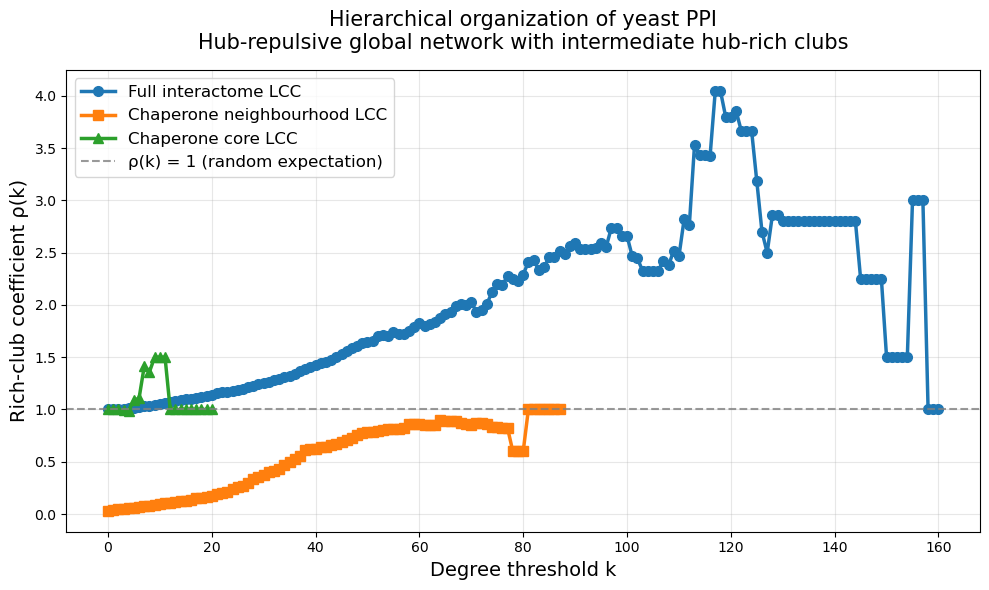


✅ Plot saved as 'rich_club_analysis.png'
Your hypothesis test is complete!


In [11]:
# PLOT RICH-CLUB CURVES 
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["tab:blue", "tab:orange", "tab:green"]
markers = ["o", "s", "^"]
labels = list(rich_club_results.keys())

for i, (name, data) in enumerate(rich_club_results.items()):
    if data["rc"] is None:
        continue
    k_vals = [k for k, rho in data["rc"]]
    rho_vals = [rho for k, rho in data["rc"]]
    ax.plot(k_vals, rho_vals, marker=markers[i], label=name, color=colors[i], linewidth=2.5, markersize=7)

ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.8, label='ρ(k) = 1 (random expectation)')
ax.set_xlabel('Degree threshold k', fontsize=14)
ax.set_ylabel('Rich-club coefficient ρ(k)', fontsize=14)
ax.set_title('Hierarchical organization of yeast PPI\n'
             'Hub-repulsive global network with intermediate hub-rich clubs', fontsize=15, pad=15)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Optional zoom (uncomment if your max k is high)
# ax.set_xlim(0, 60)

plt.tight_layout()
#plt.savefig("rich_club_analysis.png", dpi=350, bbox_inches='tight')
plt.show()

print("\n✅ Plot saved as 'rich_club_analysis.png'")
print("Your hypothesis test is complete!")